## Merged pair analysis (FG diff + Stereo diff)

`pairs_fg_stereo_merged.csv`: Integrated dataset from outer join of FG-diff-only and Stereo-diff-only (loose) pairs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/ssd1/jueon/wj/detoxicity_model/molecular_feature"
df = pd.read_csv(f"{BASE}/pairs_fg_stereo_merged.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head(2)

Shape: 16,599 rows × 43 columns
Columns: ['dataset_name', 'endpoint', 'toxic_smiles', 'nontoxic_smiles', 'toxic_scaffold_smiles', 'nontoxic_scaffold_smiles', 'tanimoto_sim', 'delta_MW', 'delta_logP', 'delta_TPSA', 'delta_HBD', 'delta_HBA', 'delta_RotB', 'delta_RingCount', 'delta_AromRingCount', 'toxic_canonical_smiles', 'nontoxic_canonical_smiles', 'toxic_fg_names', 'toxic_fg_counts', 'toxic_total_fg_count', 'toxic_fg_full', 'nontoxic_fg_names', 'nontoxic_fg_counts', 'nontoxic_total_fg_count', 'nontoxic_fg_full', 'has_fg_diff', 'unique_fg', 'toxic_chiral_centers', 'toxic_ez_bonds', 'toxic_has_chirality', 'toxic_has_ez_bonds', 'nontoxic_chiral_centers', 'nontoxic_ez_bonds', 'nontoxic_has_chirality', 'nontoxic_has_ez_bonds', 'chiral_diff_loose', 'ez_diff_loose', 'stereo_diff_type_loose', 'n_fg_diff', 'n_stereo_diff', 'n_diff_features', 'diff_type', 'step_num']


/tmp/ipykernel_1512441/1583134008.py:5: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{BASE}/pairs_fg_stereo_merged.csv")


,dataset_name,endpoint,toxic_smiles,nontoxic_smiles,toxic_scaffold_smiles,nontoxic_scaffold_smiles,tanimoto_sim,delta_MW,delta_logP,delta_TPSA,...,nontoxic_has_chirality,nontoxic_has_ez_bonds,chiral_diff_loose,ez_diff_loose,stereo_diff_type_loose,n_fg_diff,n_stereo_diff,n_diff_features,diff_type,step_num
0,sider_train,Blood and lymphatic system disorders,COCCc1ccc(OCC(O)CNC(C)C)cc1,COC(=O)CCc1ccc(OCC(O)CNC(C)C)cc1,c1ccccc1,c1ccccc1,0.704545,27.994915,0.0833,17.07,...,NaN,NaN,NaN,NaN,NaN,5,0,5,only_fg,multi_step
1,sider_train,Blood and lymphatic system disorders,CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O...,CC1CC2C3CCC4=CC(=O)C=CC4(C)[C@@]3(F)C(O)CC2(C)...,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,0.847458,17.966113,1.2465,20.23,...,True,False,True,False,chiral_only,2,2,4,both,multi_step


In [2]:
# FG diff / Stereo diff 여부 플래그
has_fg = (df["has_fg_diff"] == True)
has_stereo = df["stereo_diff_type_loose"].notna() & (df["stereo_diff_type_loose"].astype(str).str.strip() != "")

fg_only = has_fg & ~has_stereo
stereo_only = ~has_fg & has_stereo
both = has_fg & has_stereo

print("=== Pair count by diff type ===")
print(f"  FG diff only:     {fg_only.sum():,}")
print(f"  Stereo diff only: {stereo_only.sum():,}")
print(f"  Both:            {both.sum():,}")
print(f"  (Neither:        {(~has_fg & ~has_stereo).sum():,})")

=== Pair count by diff type ===
  FG diff only:     14,346
  Stereo diff only: 195
  Both:            2,058
  (Neither:        0)


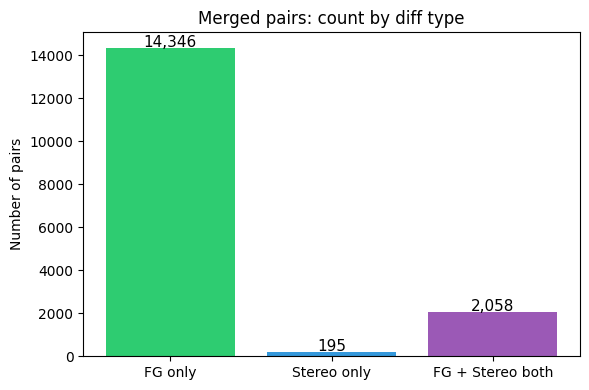

In [3]:
# Bar chart: count by diff type
fig, ax = plt.subplots(figsize=(6, 4))
counts = {"FG only": fg_only.sum(), "Stereo only": stereo_only.sum(), "FG + Stereo both": both.sum()}
ax.bar(counts.keys(), counts.values(), color=["#2ecc71", "#3498db", "#9b59b6"])
ax.set_ylabel("Number of pairs")
ax.set_title("Merged pairs: count by diff type")
for k, v in counts.items():
    ax.text(list(counts.keys()).index(k), v + 50, f"{v:,}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

=== Pair count by dataset_name ===
dataset_name
herg_central     10852
herg_karim        3752
sider_train        931
tox21_df           706
ames               233
herg                60
dilist              25
clintox             20
dictrank            14
diril                3
skin_reaction        3


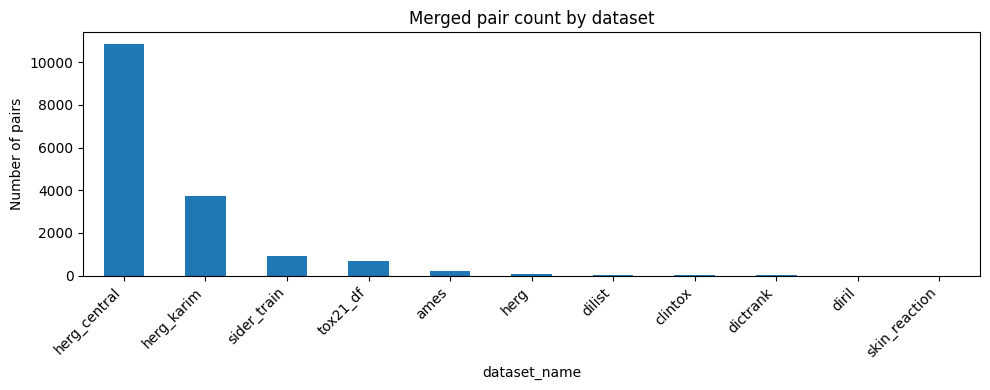

In [4]:
# Pair count by dataset (all merged pairs)
print("=== Pair count by dataset_name ===")
ds_counts = df["dataset_name"].value_counts()
print(ds_counts.to_string())
ds_counts.plot(kind="bar", figsize=(10, 4), title="Merged pair count by dataset")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of pairs")
plt.tight_layout()
plt.show()

### Per endpoint: pair count and unique toxic / nontoxic SMILES

For each (dataset_name, endpoint), count how many pairs there are and how many **unique** toxic_smiles and nontoxic_smiles appear in those pairings.

In [5]:
# Per (dataset_name, endpoint): n_pairs, n_unique_toxic_smiles, n_unique_nontoxic_smiles
per_endpoint = df.groupby(["dataset_name", "endpoint"]).agg(
    n_pairs=("toxic_smiles", "size"),
    n_unique_toxic_smiles=("toxic_smiles", "nunique"),
    n_unique_nontoxic_smiles=("nontoxic_smiles", "nunique"),
).reset_index()
per_endpoint = per_endpoint.sort_values("n_pairs", ascending=False)
print("Per endpoint (dataset_name, endpoint):")
print(per_endpoint.head(30).to_string())
per_endpoint.head(20)

Per endpoint (dataset_name, endpoint):
    dataset_name                                         endpoint  n_pairs  n_unique_toxic_smiles  n_unique_nontoxic_smiles
6   herg_central                                       hERG_inhib    10852                   5362                      8270
7     herg_karim                                       herg_karim     3752                   1298                      1371
0           ames                                             ames      233                    183                       151
40      tox21_df                                      tox21_NR-ER      135                    103                       119
46      tox21_df                                     tox21_SR-MMP      112                     78                        72
39      tox21_df                               tox21_NR-Aromatase       87                     27                        29
43      tox21_df                                     tox21_SR-ARE       75                   

,dataset_name,endpoint,n_pairs,n_unique_toxic_smiles,n_unique_nontoxic_smiles
6,herg_central,hERG_inhib,10852,5362,8270
7,herg_karim,herg_karim,3752,1298,1371
0,ames,ames,233,183,151
40,tox21_df,tox21_NR-ER,135,103,119
46,tox21_df,tox21_SR-MMP,112,78,72
39,tox21_df,tox21_NR-Aromatase,87,27,29
43,tox21_df,tox21_SR-ARE,75,44,43
41,tox21_df,tox21_NR-ER-LBD,63,44,48
5,herg,herg,60,46,21
38,tox21_df,tox21_NR-AhR,59,36,54


In [6]:
# Pairs with both FG diff and Stereo diff, by dataset
both_df = df.loc[both]
print("=== Pairs with both FG diff & Stereo diff — by dataset ===")
print(both_df["dataset_name"].value_counts().to_string())
print(f"\nTotal: {len(both_df):,}")

=== Pairs with both FG diff & Stereo diff — by dataset ===
dataset_name
herg_karim      1275
sider_train      350
herg_central     260
tox21_df         109
ames              31
herg              14
clintox            9
dilist             5
dictrank           3
diril              2

Total: 2,058


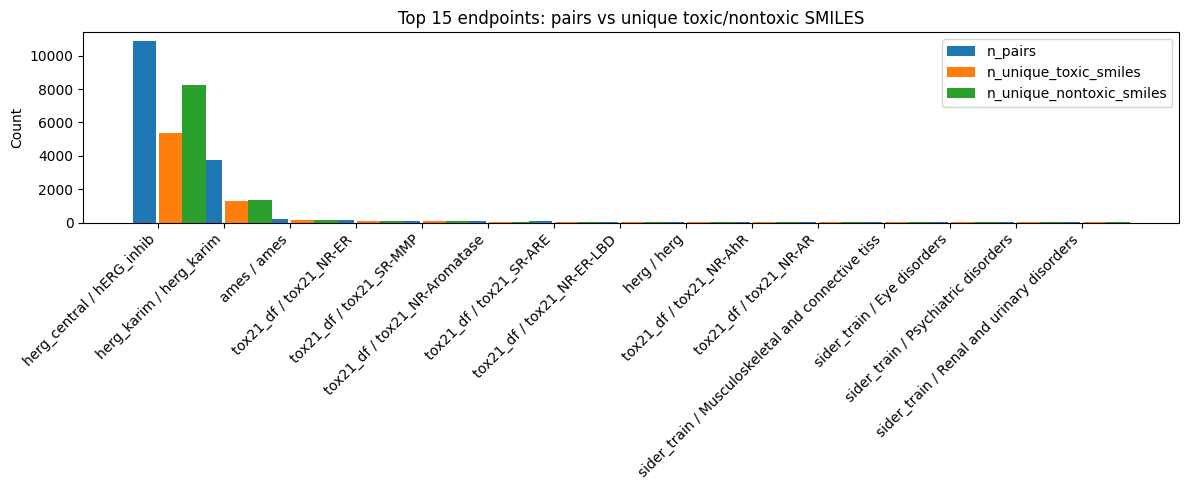

In [7]:
# Bar: top 15 endpoints by pair count (label = dataset + endpoint)
top = per_endpoint.head(15)
labels = top["dataset_name"].astype(str) + " / " + top["endpoint"].str.slice(0, 35)
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(top))
ax.bar([i - 0.2 for i in x], top["n_pairs"], width=0.35, label="n_pairs")
ax.bar([i + 0.2 for i in x], top["n_unique_toxic_smiles"], width=0.35, label="n_unique_toxic_smiles")
ax.bar([i + 0.55 for i in x], top["n_unique_nontoxic_smiles"], width=0.35, label="n_unique_nontoxic_smiles")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Top 15 endpoints: pairs vs unique toxic/nontoxic SMILES")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Stereo diff type (loose): chiral_only / ez_only / both
print("=== Stereo diff type (stereo_diff_type_loose) ===")
print(df.loc[has_stereo, "stereo_diff_type_loose"].value_counts().to_string())

=== Stereo diff type (stereo_diff_type_loose) ===
stereo_diff_type_loose
chiral_only    1976
ez_only         250
both             27


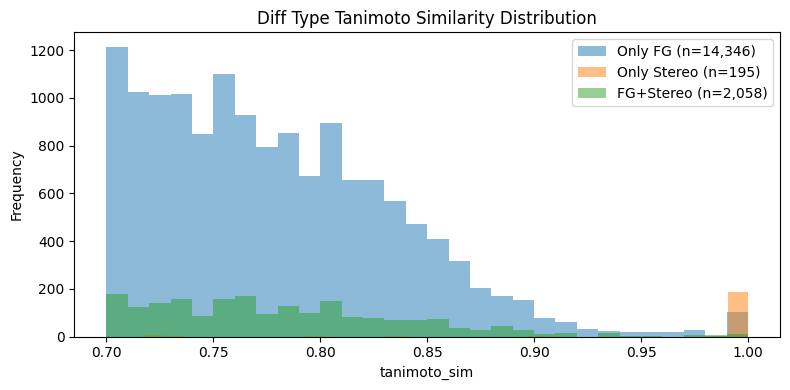

In [9]:
# Tanimoto 유사도 분포: Diff 유형별
fig, ax = plt.subplots(figsize=(8, 4))
for label, mask in [("Only FG", fg_only), ("Only Stereo", stereo_only), ("FG+Stereo", both)]:
    ax.hist(df.loc[mask, "tanimoto_sim"].dropna(), bins=30, alpha=0.5, label=f"{label} (n={mask.sum():,})")
ax.set_xlabel("tanimoto_sim")
ax.set_ylabel("Frequency")
ax.set_title("Diff Type Tanimoto Similarity Distribution")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
print(df.columns)
df.head(2)

Index(['dataset_name', 'endpoint', 'toxic_smiles', 'nontoxic_smiles',
       'toxic_scaffold_smiles', 'nontoxic_scaffold_smiles', 'tanimoto_sim',
       'delta_MW', 'delta_logP', 'delta_TPSA', 'delta_HBD', 'delta_HBA',
       'delta_RotB', 'delta_RingCount', 'delta_AromRingCount',
       'toxic_canonical_smiles', 'nontoxic_canonical_smiles', 'toxic_fg_names',
       'toxic_fg_counts', 'toxic_total_fg_count', 'toxic_fg_full',
       'nontoxic_fg_names', 'nontoxic_fg_counts', 'nontoxic_total_fg_count',
       'nontoxic_fg_full', 'has_fg_diff', 'unique_fg', 'toxic_chiral_centers',
       'toxic_ez_bonds', 'toxic_has_chirality', 'toxic_has_ez_bonds',
       'nontoxic_chiral_centers', 'nontoxic_ez_bonds',
       'nontoxic_has_chirality', 'nontoxic_has_ez_bonds', 'chiral_diff_loose',
       'ez_diff_loose', 'stereo_diff_type_loose', 'n_fg_diff', 'n_stereo_diff',
       'n_diff_features', 'diff_type', 'step_num'],
      dtype='object')


,dataset_name,endpoint,toxic_smiles,nontoxic_smiles,toxic_scaffold_smiles,nontoxic_scaffold_smiles,tanimoto_sim,delta_MW,delta_logP,delta_TPSA,...,nontoxic_has_chirality,nontoxic_has_ez_bonds,chiral_diff_loose,ez_diff_loose,stereo_diff_type_loose,n_fg_diff,n_stereo_diff,n_diff_features,diff_type,step_num
0,sider_train,Blood and lymphatic system disorders,COCCc1ccc(OCC(O)CNC(C)C)cc1,COC(=O)CCc1ccc(OCC(O)CNC(C)C)cc1,c1ccccc1,c1ccccc1,0.704545,27.994915,0.0833,17.07,...,NaN,NaN,NaN,NaN,NaN,5,0,5,only_fg,multi_step
1,sider_train,Blood and lymphatic system disorders,CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O...,CC1CC2C3CCC4=CC(=O)C=CC4(C)[C@@]3(F)C(O)CC2(C)...,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,0.847458,17.966113,1.2465,20.23,...,True,False,True,False,chiral_only,2,2,4,both,multi_step


In [11]:
fg_mask = df[["has_fg_diff"]].notna().any(axis=1)
stereo_mask = df[["stereo_diff_type_loose"]].notna().any(axis=1)
both_mask = df[["has_fg_diff", "stereo_diff_type_loose"]].notna().any(axis=1)
fg_df = df[fg_mask]
stereo_df = df[stereo_mask]
both_df = df[both_mask]

In [12]:
print(fg_df['n_fg_diff'].value_counts())
print(fg_df['n_fg_diff'].describe())
fg_df.head(2)

n_fg_diff
5     3092
6     2819
4     2562
2     2393
3     1808
7     1745
8      902
1      759
9      245
10      55
11      24
Name: count, dtype: int64
count    16404.000000
mean         4.635516
std          1.996335
min          1.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         11.000000
Name: n_fg_diff, dtype: float64


,dataset_name,endpoint,toxic_smiles,nontoxic_smiles,toxic_scaffold_smiles,nontoxic_scaffold_smiles,tanimoto_sim,delta_MW,delta_logP,delta_TPSA,...,nontoxic_has_chirality,nontoxic_has_ez_bonds,chiral_diff_loose,ez_diff_loose,stereo_diff_type_loose,n_fg_diff,n_stereo_diff,n_diff_features,diff_type,step_num
0,sider_train,Blood and lymphatic system disorders,COCCc1ccc(OCC(O)CNC(C)C)cc1,COC(=O)CCc1ccc(OCC(O)CNC(C)C)cc1,c1ccccc1,c1ccccc1,0.704545,27.994915,0.0833,17.07,...,NaN,NaN,NaN,NaN,NaN,5,0,5,only_fg,multi_step
1,sider_train,Blood and lymphatic system disorders,CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O...,CC1CC2C3CCC4=CC(=O)C=CC4(C)[C@@]3(F)C(O)CC2(C)...,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,0.847458,17.966113,1.2465,20.23,...,True,False,True,False,chiral_only,2,2,4,both,multi_step


### One toxic SMILES paired with multiple nontoxic SMILES

Find cases where the same `toxic_smiles` appears in more than one pair (with different `nontoxic_smiles`) within the same (dataset_name, endpoint).

In [13]:
# 예시: 한 toxic이 여러 nontoxic과 pairing된 경우의 실제 pair 행 보기
# (이 셀만 실행해도 동작하도록 여기서 계산)
toxic_multi = (
    df.groupby(["dataset_name", "endpoint", "toxic_smiles"], as_index=False)
    .agg(n_nontoxic_partners=("nontoxic_smiles", "nunique"), n_pairs=("nontoxic_smiles", "size"))
)
one_toxic_many_nontoxic = toxic_multi[toxic_multi["n_nontoxic_partners"] > 1].sort_values(
    "n_nontoxic_partners", ascending=False
)
if len(one_toxic_many_nontoxic) > 0:
    ex = one_toxic_many_nontoxic.iloc[0]
    mask = (
        (df["dataset_name"] == ex["dataset_name"])
        & (df["endpoint"] == ex["endpoint"])
        & (df["toxic_smiles"] == ex["toxic_smiles"])
    )
    print(f"Example: {ex['dataset_name']} / {ex['endpoint']}")
    print(f"  toxic_smiles (1개): {ex['toxic_smiles'][:80]}...")
    print(f"  → paired with {ex['n_nontoxic_partners']} different nontoxic_smiles ({ex['n_pairs']} pairs)")
    print()
    df.loc[mask, ["dataset_name", "endpoint", "toxic_smiles", "nontoxic_smiles", "tanimoto_sim"]].head(10)
else:
    print("No (dataset, endpoint, toxic_smiles) with 2+ nontoxic partners.")



Example: herg_central / hERG_inhib
  toxic_smiles (1개): CCOC(=O)[C@H]1[C@H]2COc3ccc(C)cc3[C@@H]2N2C(=O)c3cc(OC)ccc3NC(=O)[C@@]12C...
  → paired with 35 different nontoxic_smiles (35 pairs)

